# Notebook to validate blinding data:

In [ ]:
import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
for logger_name in ['jax._src.xla_bridge', 'jax._src.distributed', 'jax._src.interpreters.pxla', 'jax._src.dispatch', 
                    'jax._src.compiler', 'jax._src.cache_key', 'jax._src.compilation_cache', 'matplotlib.ticker']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

In [3]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 06-17 16:33  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/


In [35]:
def propose_fiducial(kmin=1e-3, kmax=0.08, region='GCcomb'):
    propose_fiducial = {}

    use_ell2 = True

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_mocks': 'LRG', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_mocks': 'ELGnotqso', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_mocks': 'QSO', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_mocks': 'LRGxQSO', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_mocks': 'LRGxELGnotqso', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_mocks': 'ELGnotqsoxQSO', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']
      
    return propose_fiducial

In [36]:
regions = ['NGC', 'SGC', 'GCcomb']
tracers_to_read = ['LRG', 'LRG_zcmb', 'QSO', 'ELGnotqso', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

pks = {region: {} for region in regions}
windows = {region: {} for region in regions}
covs = {region: {} for region in regions}
mocks = {region: {} for region in regions}
zeffs = {region: {} for region in regions}

for region in regions:
    for tracer in tracers_to_read:
        # reload fiducial because we will overwrite things here ... 
        fiducial = propose_fiducial(kmin=1e-3, kmax=0.08, region=region)

        short_tracer = tracer.replace('_zcmb', '')
        short_tracer = short_tracer.replace('notqso', '')

        if tracer == 'LRG_zcmb':
            fiducial[short_tracer]['weight_type'] = 'default-fkp-oqe-wsys-imlin_finezbin_allebvcmb'

        pk, window, cov, mock = read_data(
            data_dir=data_dir,
            mocks_dir=mocks_dir,
            tracer=tracer,
            **fiducial[short_tracer],
        )

        pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])

        if 'x' not in short_tracer:
            short_tracer = 'x'.join(2 * [short_tracer])

        pks[region][tracer] = pk
        windows[region][tracer] = window
        covs[region][tracer] = cov
        mocks[region][tracer] = mock

        zeffs[region][short_tracer] = {}
        zeffs[region][short_tracer][0] = windows[region][tracer].observable.get(0).attrs['zeff']
        try:
            zeffs[region][short_tracer][2] = windows[region][tracer].observable.get(2).attrs['zeff']
        except ValueError:
            pass

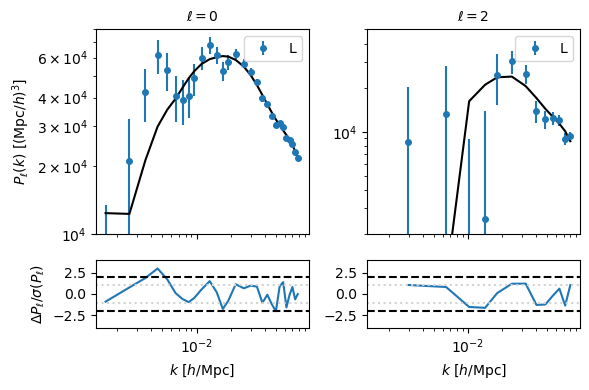

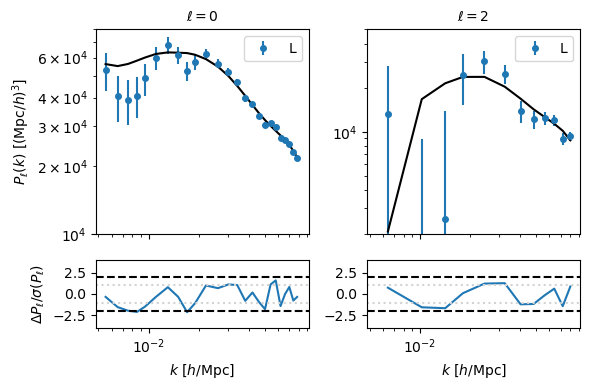

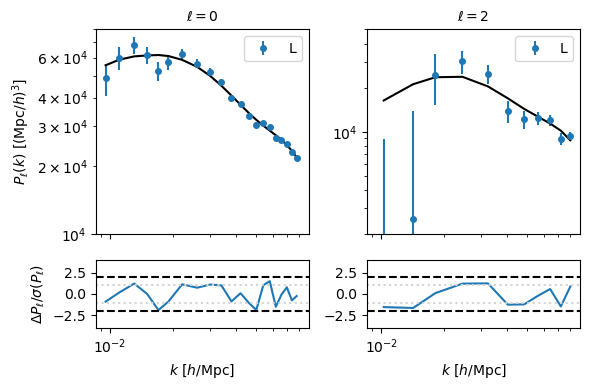

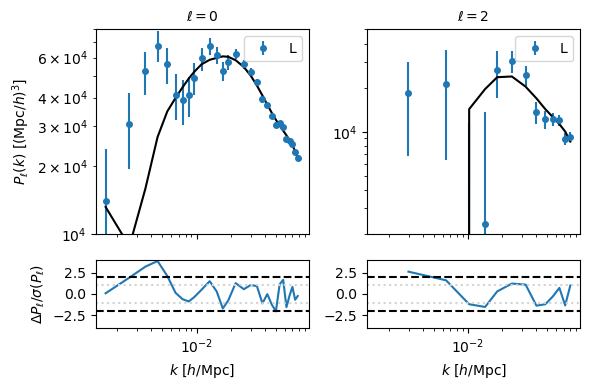

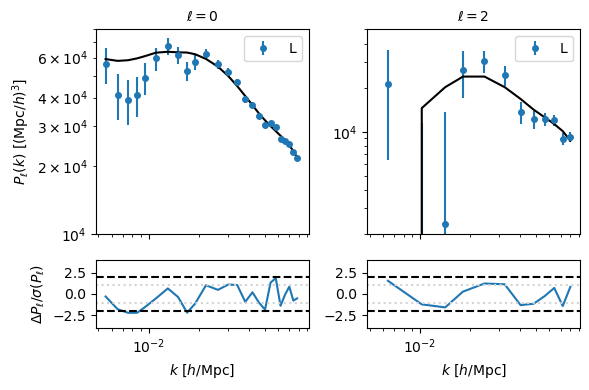

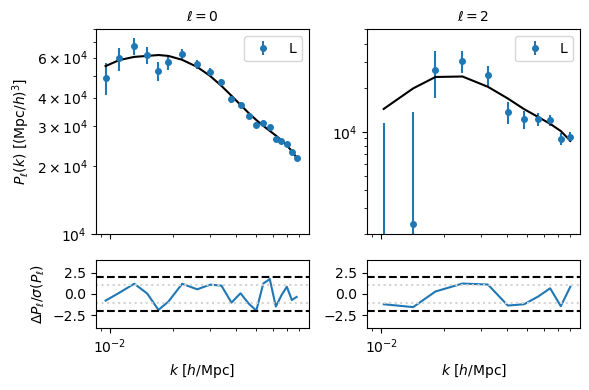

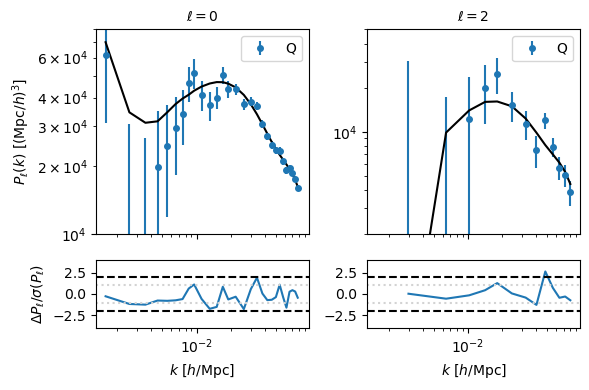

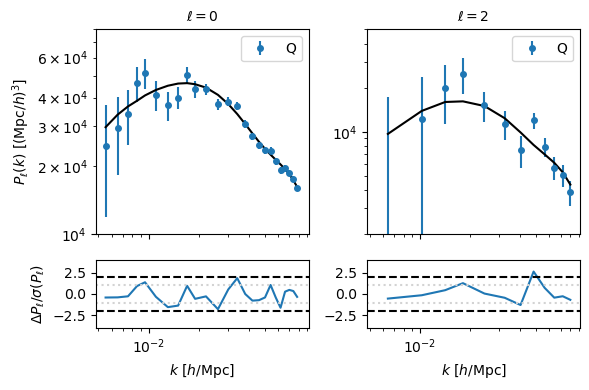

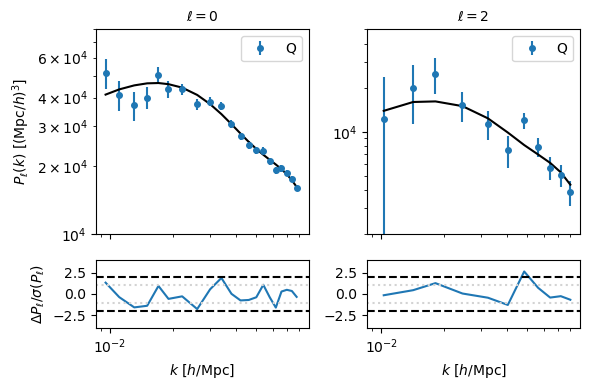

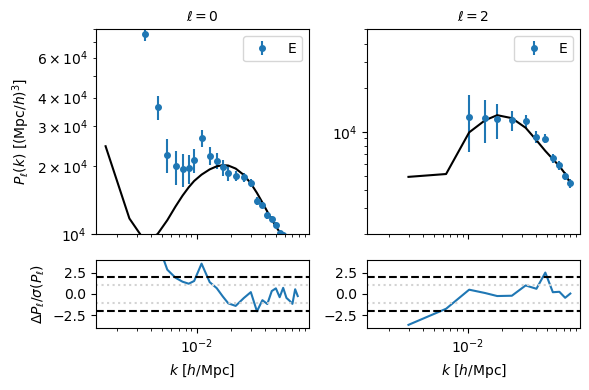

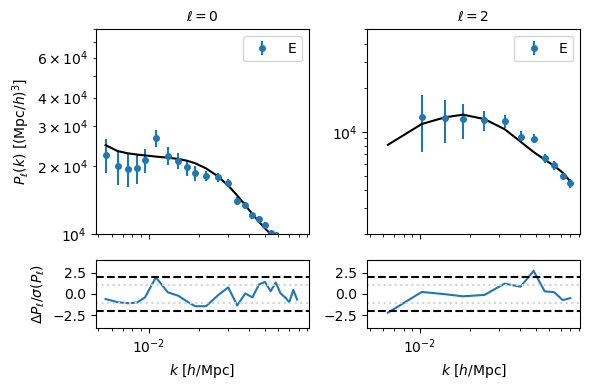

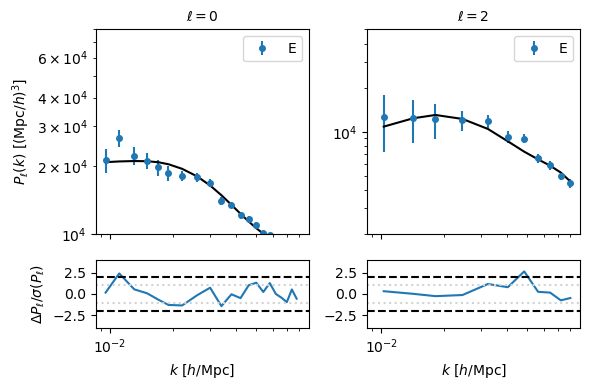

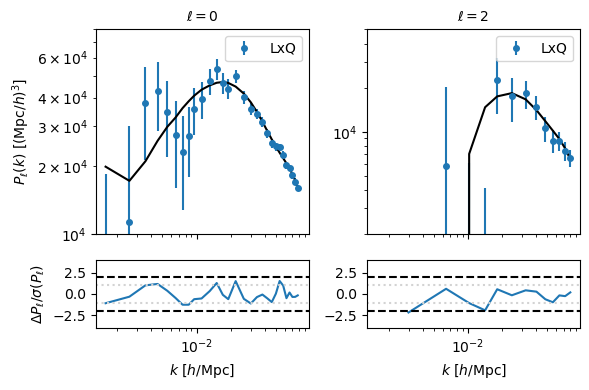

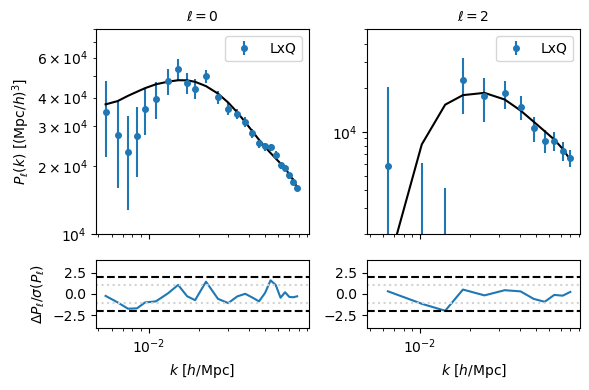

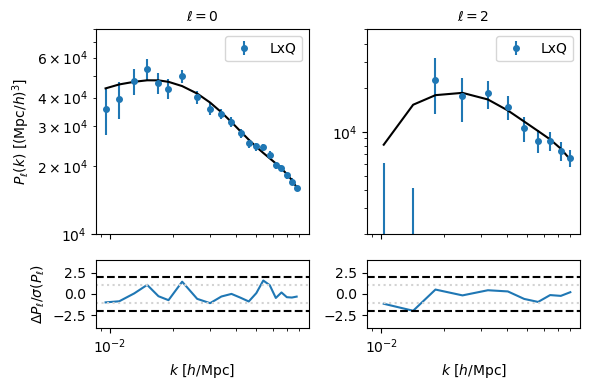

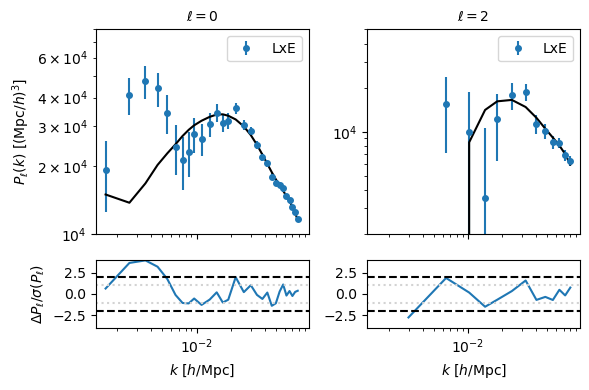

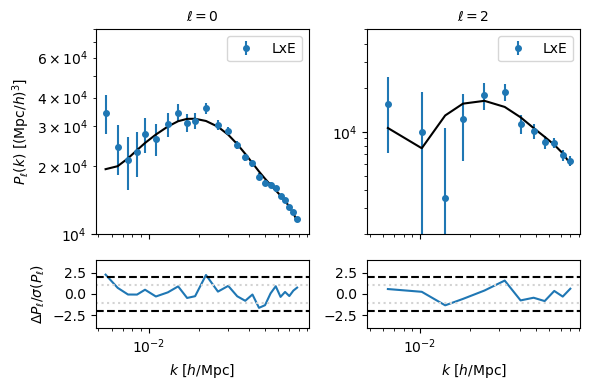

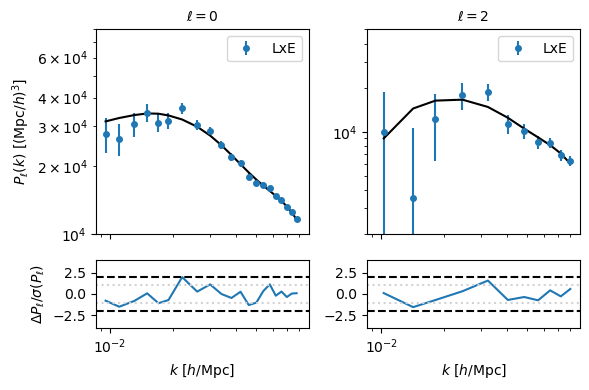

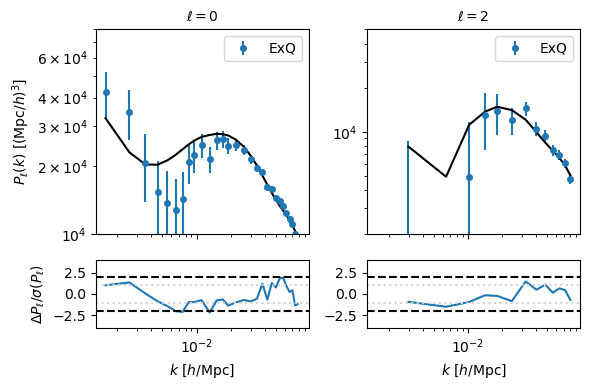

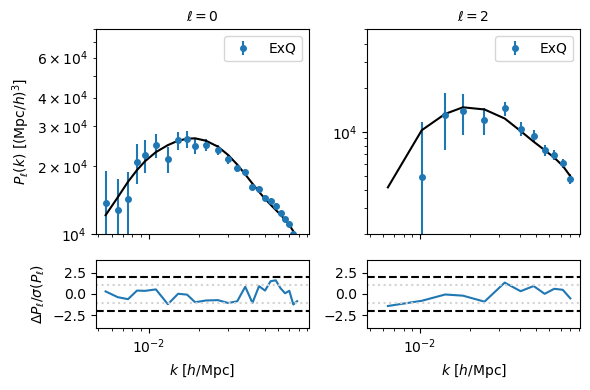

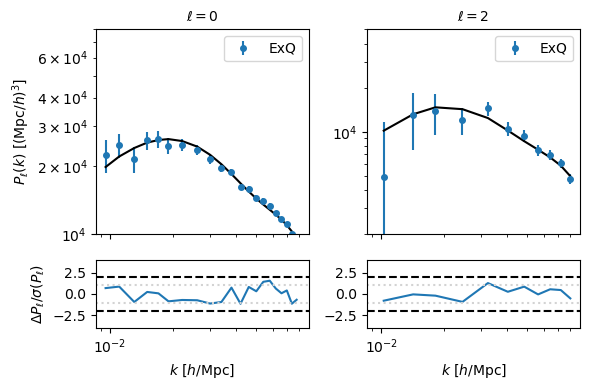

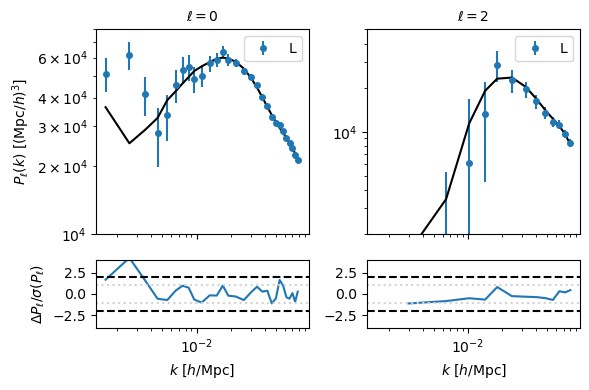

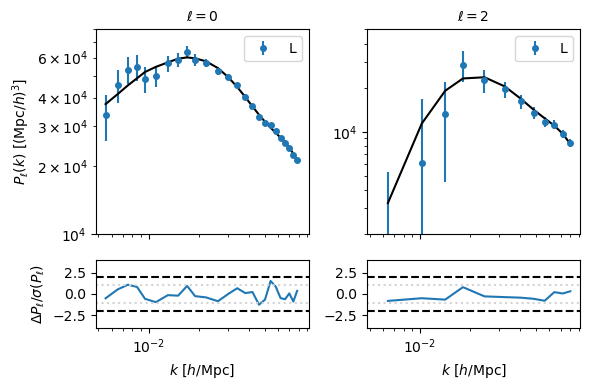

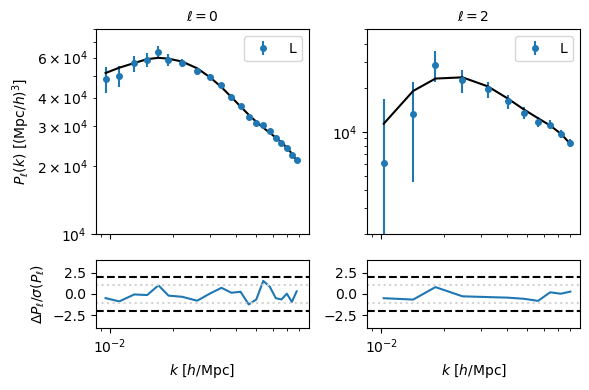

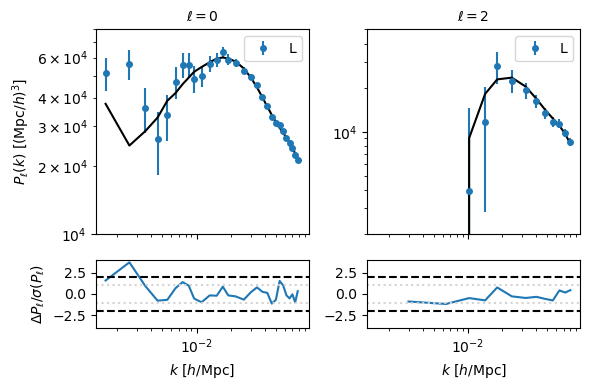

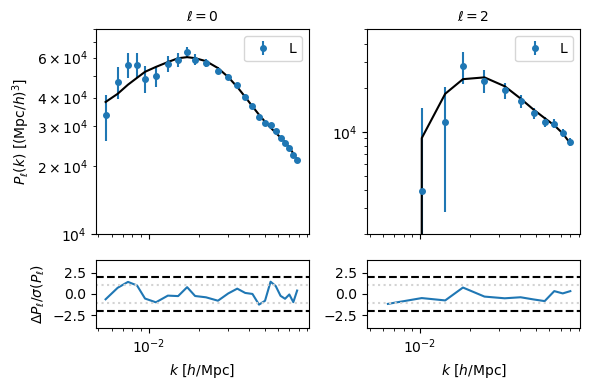

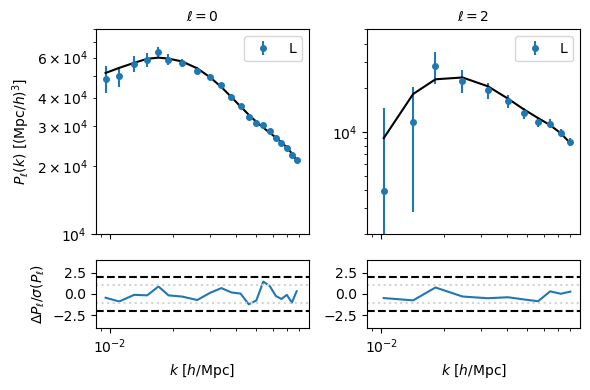

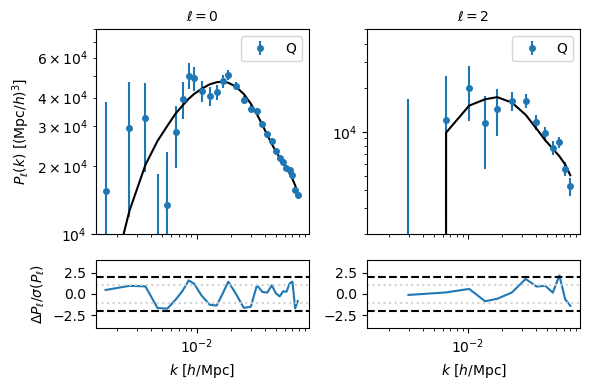

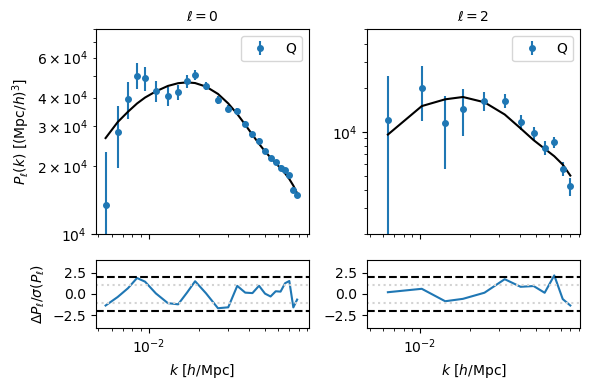

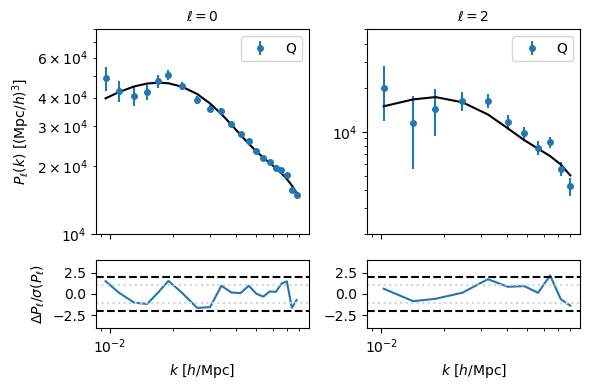

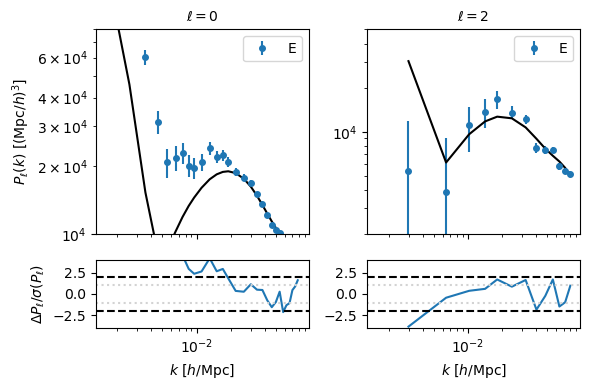

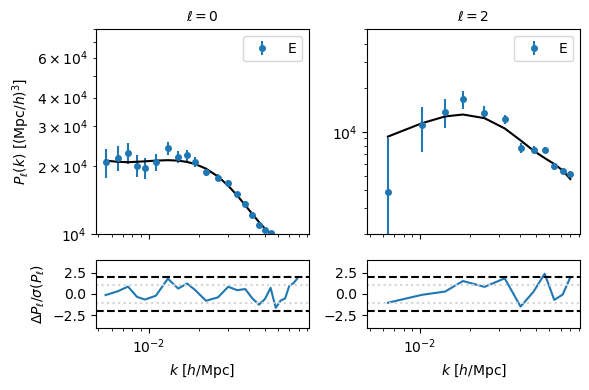

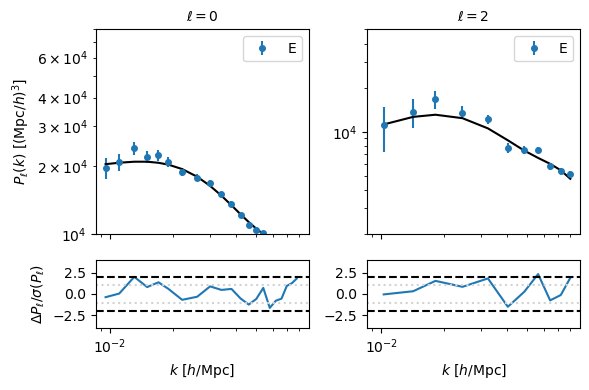

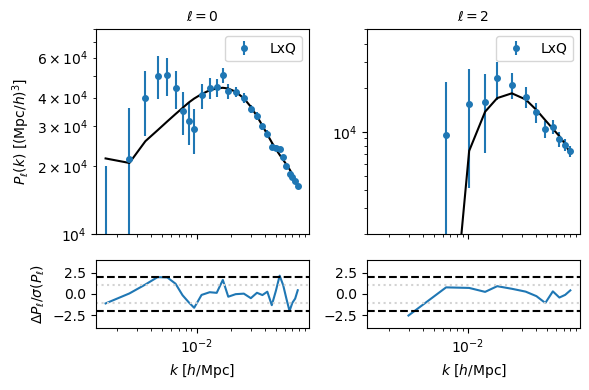

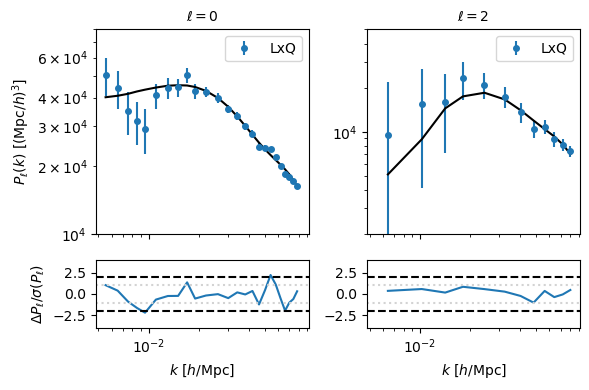

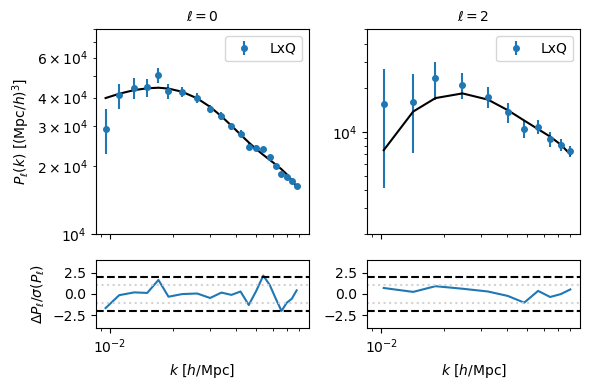

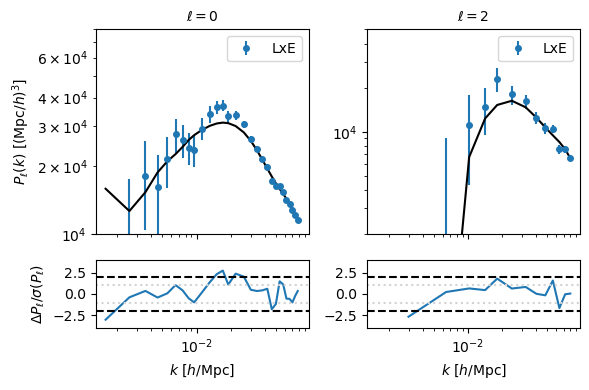

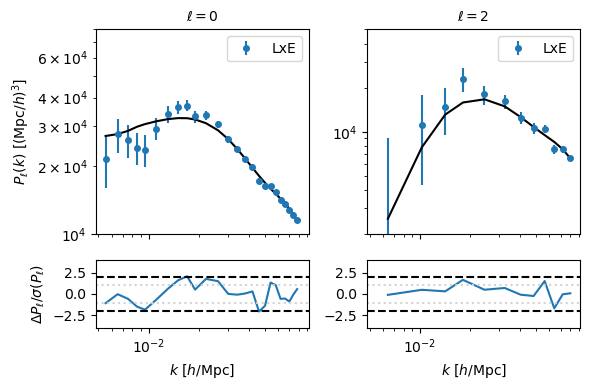

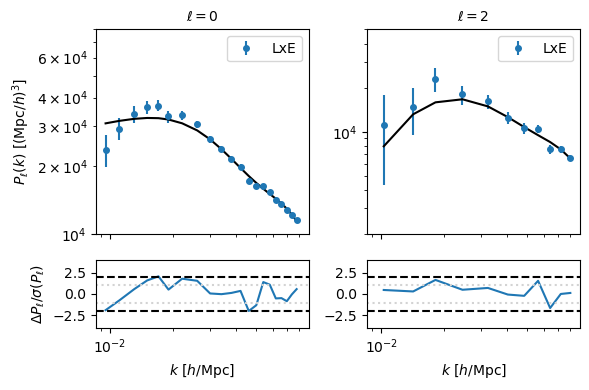

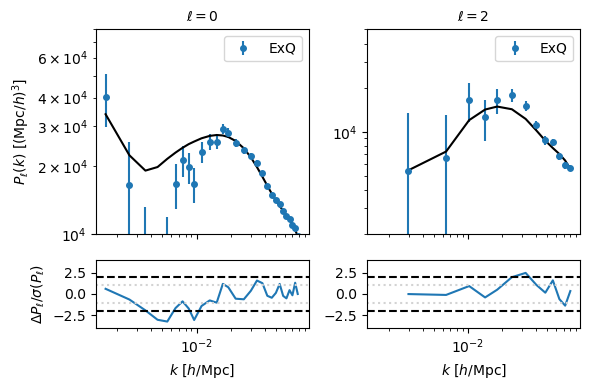

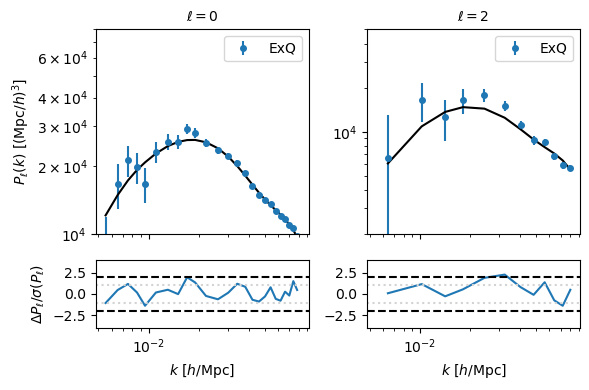

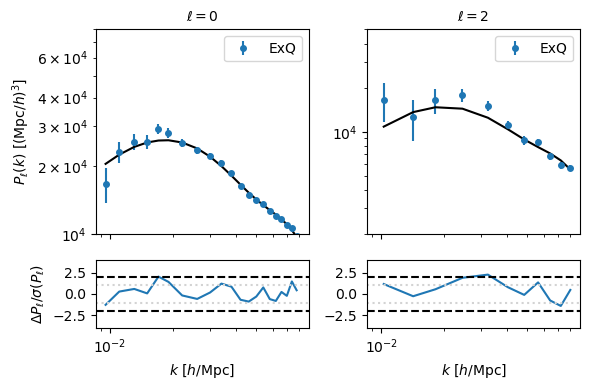

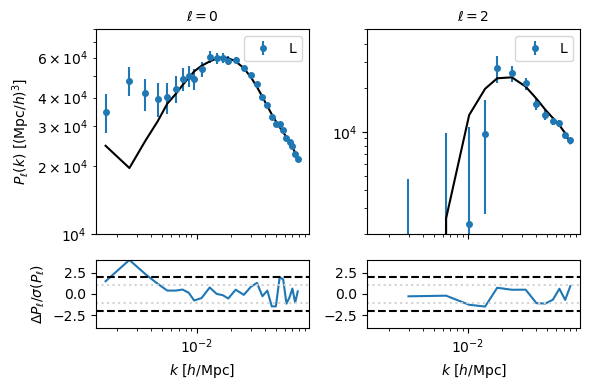

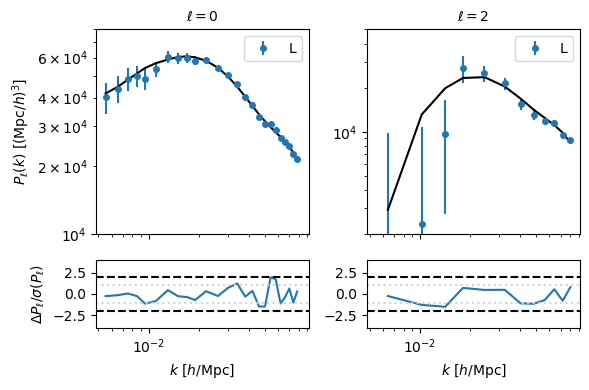

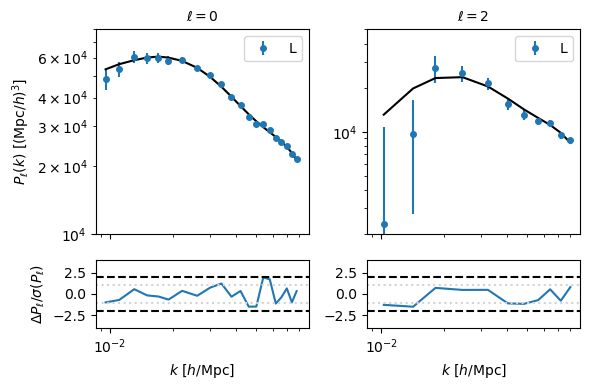

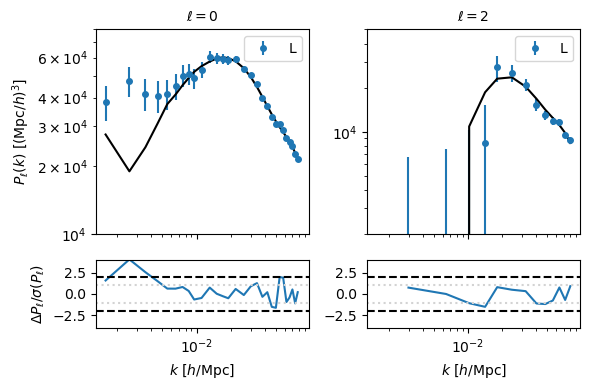

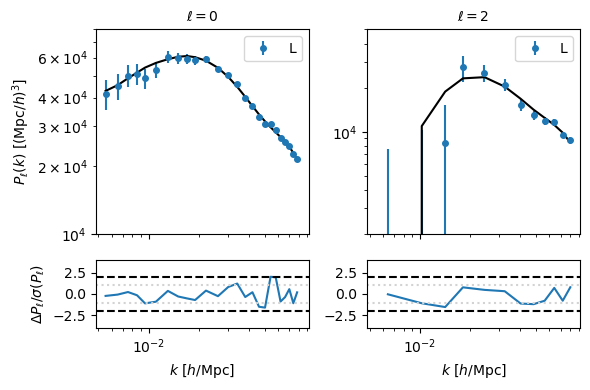

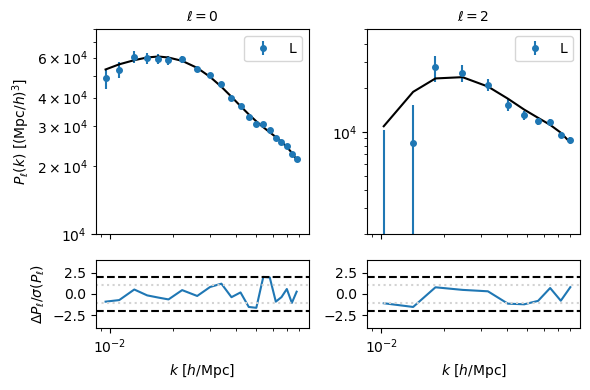

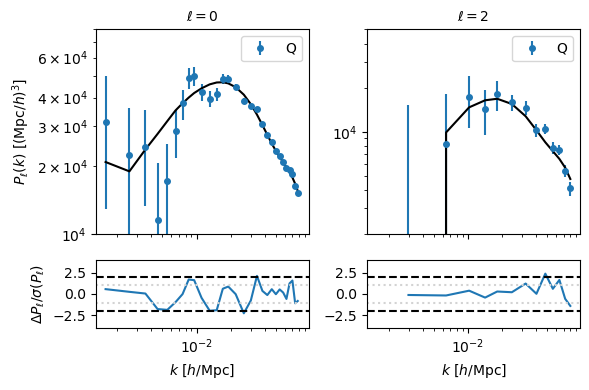

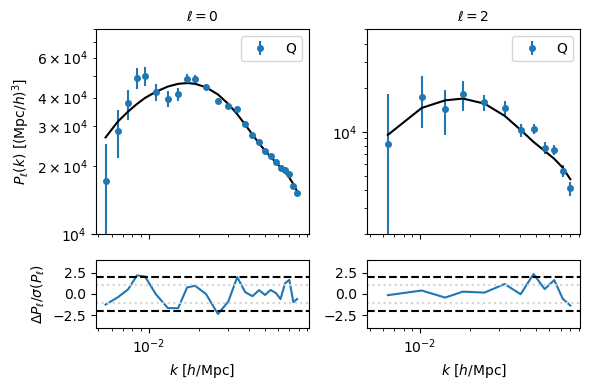

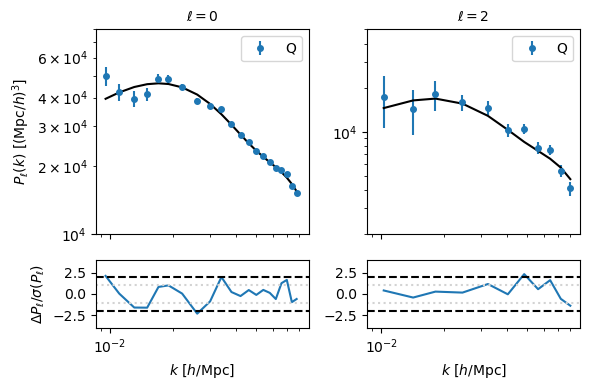

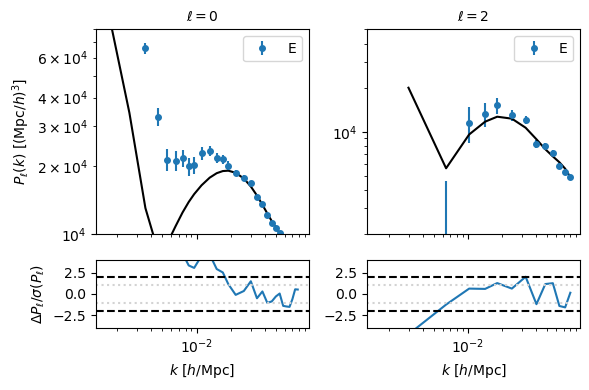

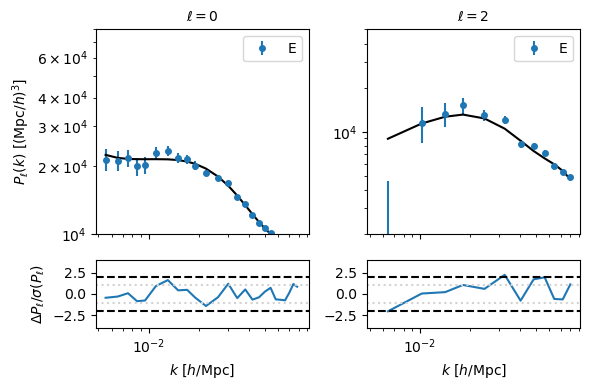

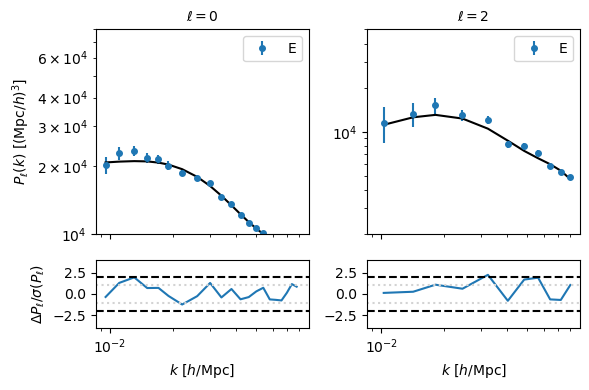

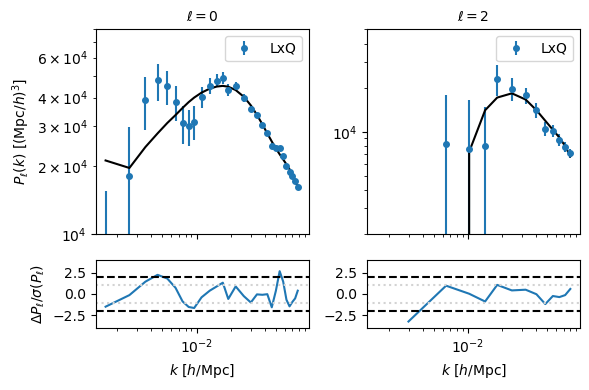

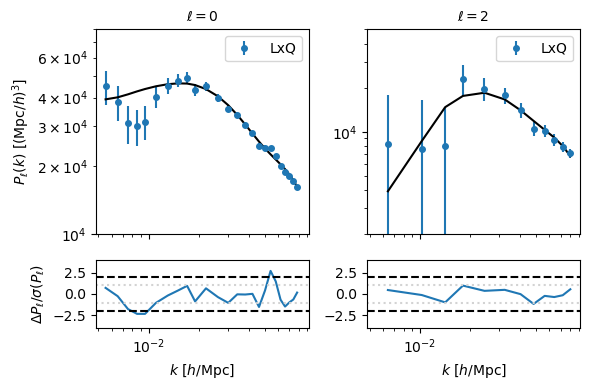

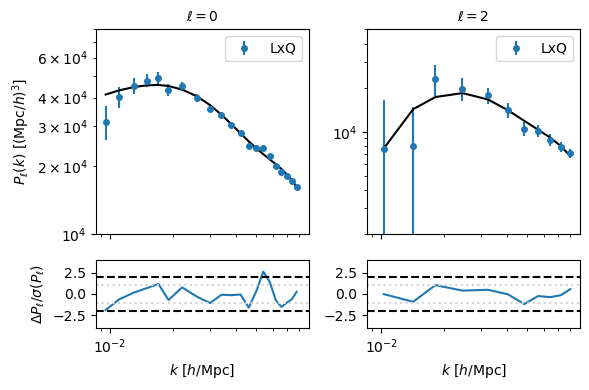

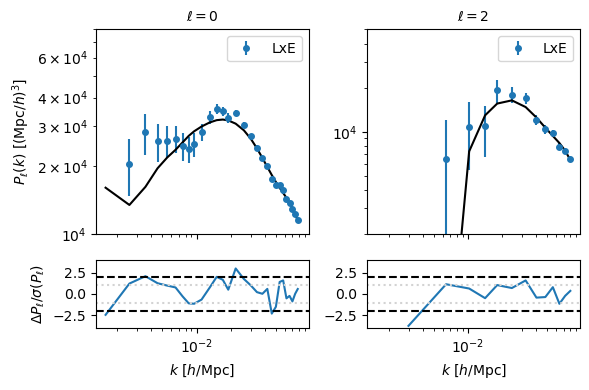

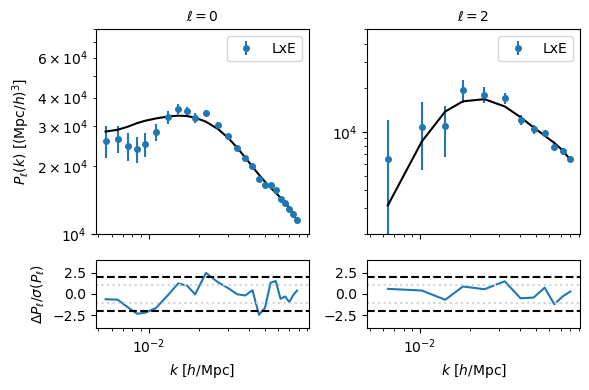

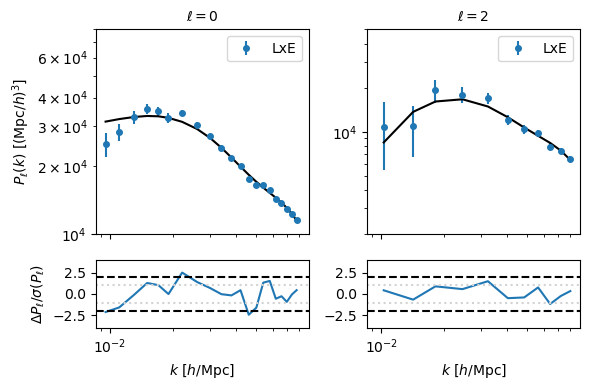

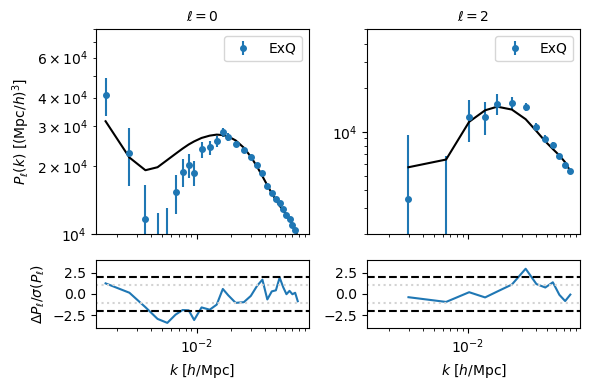

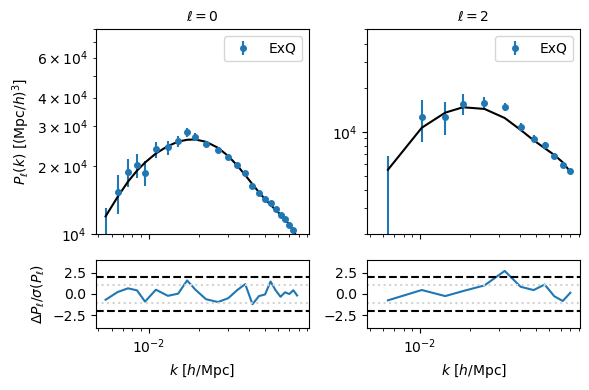

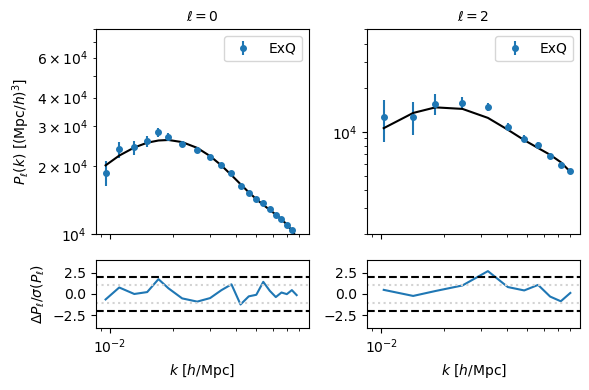

In [43]:
logging.getLogger().setLevel(logging.ERROR)

regions = ['SGC', 'NGC', 'GCcomb']

kmins = [1e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 9e-3]

profs = {}
for region in regions:
    for tracer in tracers_to_read:
        short_tracer = tracer.replace('_zcmb', '').replace('notqso', '')

        kwargs = {'scale_covariance': 1}
        if 'x' in short_tracer:
            from clustering_statistics.tools import bias
            tt1 = short_tracer.split('x')[0]
            kwargs[f'{tt1}_{short_tracer}_ell0.b1'] = bias(zeffs[region][short_tracer][0], tracer=tt1)
        #print(kwargs)

        for kmin in kmins:

            pp = pks[region][tracer].select(k=(kmin, 0.2))
            ww = windows[region][tracer].at.observable.match(pp)
            mm = [mock.match(pp) for mock in mocks[region][tracer]]

            obs, lik = get_observable_and_likelihood(pp, ww, mm, short_tracer, zeffs[region], nickname=short_tracer, engine='camb', **kwargs)
            profs[(region, tracer, kmin)] = run_profiler(lik)

            if kmin in kmins[::3]: plot_observables({short_tracer: obs})

logging.getLogger().setLevel(logging.INFO)

In [71]:
import os
from lsstypes.utils import get_percival2014_factor


def get_val_err(prof, param, sigfigs=4):
    """Single-param lookup, kept for use elsewhere."""
    val, err = prof.profiles.to_stats(tablefmt='list', sigfigs=sigfigs, params=[param])[0][0][2:]
    return float(val), np.nan if err == '' else float(err)


def get_vals_errs(prof, params, sigfigs=4):
    """Fetch (value, error) for several params in one to_stats() call instead of one per param."""
    rows = prof.profiles.to_stats(tablefmt='list', sigfigs=sigfigs, params=params)[0]
    # assumes rows come back in the same order as `params` -- worth a quick sanity check
    # the first time you run this (e.g. len(rows) == len(params))
    return {p: (float(v), np.nan if e == '' else float(e)) for p, (_, _, v, e) in zip(params, rows)}


def get_correct_factor(nparams, mocks, kmins, return_ndof=False):
    nmocks = len(mocks)
    factor, ndof_list = [], []
    for kmin in kmins:
        nbins = mocks[0].select(k=(kmin, 1)).size
        ndof = nbins - nparams
        factor.append(get_percival2014_factor(nmocks, nbins, nparams) / ndof)
        #factor.append(1 / ndof)
        ndof_list.append(ndof)
    if return_ndof:
        return np.array(factor), np.array(ndof_list)
    return np.array(factor)

In [73]:

def plot_chi2_diagnostics(tt, profs, mocks, regions, kmins, ref_region='GCcomb', outdir='fig_data'):
    os.makedirs(outdir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(4, 2.7))
    for region in regions:
        nparams = sum(row[-1] != '' for row in
                       profs[(region, tt, kmins[0])].profiles.to_stats(tablefmt='list')[0])
        factor, ndof = get_correct_factor(nparams, mocks[region][tt], kmins, return_ndof=True)
        logpost = np.array([get_val_err(profs[(region, tt, kmin)], 'logposterior')[0] for kmin in kmins])
        red_chi2 = -2 * logpost * factor

        if region == ref_region:
            ax.plot(kmins, red_chi2, 'k--', lw=2, label=region, zorder=3)
        else:
            ax.plot(kmins, red_chi2, 'o-', label=region)

    ax.axhline(1, color='k', ls=':')
    ax.fill_between(kmins, 1 - 1/np.sqrt(ndof), 1 + 1/np.sqrt(ndof), color='gray', alpha=0.1)
    ax.set_ylim(0.5, 1.6)
    ax.set_xlabel('kmin')
    ax.set_ylabel('reduced chi2')
    ax.set_title(tt)
    ax.legend(ncol=len(regions))
    fig.tight_layout()
    fig.savefig(f'{outdir}/chi2_{tt}.png', dpi=400)
    plt.show()
    plt.close(fig)


def plot_param_diagnostics(tt, profs, mocks, regions, kmins, sigfigs=4,
                            outdir='fig_data', ref_region='GCcomb'):
    os.makedirs(outdir, exist_ok=True)

    tt_clean = tt.replace('_zcmb', '').replace('notqso', '')
    if 'x' in tt_clean:
        t1, t2 = tt_clean.split('x')
        params = ['fnl_loc', f'{t2}_{tt_clean}_ell0.b1',
                  f'{t1}_{tt_clean}_ell0x{t2}_{tt_clean}_ell0.sn0',
                  f'{t2}_{tt_clean}_ell0.sigmas']
    else:
        params = ['fnl_loc', f'{tt_clean}_ell0.b1', f'{tt_clean}_ell0.sigmas',
                  f'{tt_clean}_ell0.sn0']

    other_regions = [r for r in regions if r != ref_region]
    region_color = {r: f'C{i}' for i, r in enumerate(other_regions)}

    region_stats = {region: [get_vals_errs(profs[(region, tt, kmin)], params, sigfigs=sigfigs)
                              for kmin in kmins]
                     for region in regions}

    fig, axes = plt.subplots(2, len(params), figsize=(10, 4), sharex=True,
                              gridspec_kw=dict(height_ratios=[2, 1]))

    for j, param in enumerate(params):
        ax_top, ax_bot = axes[0, j], axes[1, j]

        ref_vals = np.array([s[param][0] for s in region_stats[ref_region]])
        ref_errs = np.array([s[param][1] for s in region_stats[ref_region]])
        ax_top.plot(kmins, ref_vals, 'k-', lw=1.5, zorder=3)
        ax_top.fill_between(kmins, ref_vals - ref_errs, ref_vals + ref_errs,
                             color='k', alpha=0.15, label=ref_region, zorder=2)

        ax_bot.axhline(0, color='k', ls='--')
        ax_bot.fill_between(kmins, -1, 1, color='gray', alpha=0.1)

        for region in other_regions:
            vals = np.array([s[param][0] for s in region_stats[region]])
            errs = np.array([s[param][1] for s in region_stats[region]])
            ax_top.errorbar(kmins, vals, yerr=errs, ls=':', fmt='o',
                             color=region_color[region], label=region)
            ax_bot.plot(kmins, (vals - ref_vals) / errs, 'o-', color=region_color[region])

        ax_top.set_ylabel(param.split('.')[-1])
        ax_bot.set_ylabel(f'pull vs {ref_region}')
        ax_bot.set_xlabel('kmin')
        ax_bot.set_ylim(-3, 3)

        ax_top.axvline(5e-3, color='gray', ls='--')
        ax_top.axvline(3e-3, color='gray', ls='--')

    axes[0, 0].legend(ncol=1)
    fig.suptitle(tt, y=0.95)
    fig.tight_layout()
    fig.savefig(f'{outdir}/params_{tt}.png', dpi=400)
    plt.show()
    plt.close(fig)


for tt in ['LRG', 'LRG_zcmb', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO', 'ELGnotqso']:
    plot_param_diagnostics(tt, profs, mocks, regions, kmins)
    plot_chi2_diagnostics(tt, profs, mocks, regions, kmins)

KeyError: ('SGC', 'LRG', 0.002)

GCcomb 0.001 +-------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 43.26 / 38 = 1.14 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -8.2   |  2.9  |
|            QSO_ell0.sn0             |  True  | -0.149  | 0.054 |
|             QSO_ell0.b1             |  True  |  3.230  | 0.044 |
|           QSO_ell0.sigmas           |  True  |  3.91   | 0.50  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.9   |       |
+-------------------------------------+--------+---------+-------+


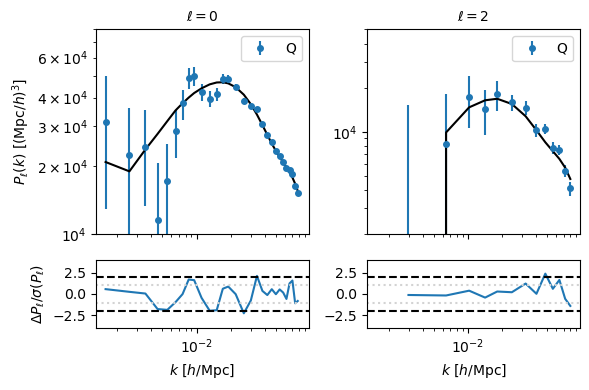

GCcomb 0.002 +-------------------------------------+--------+---------+-------+
| chi2 / (41 - 4) = 42.77 / 37 = 1.16 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -1.6   |  7.7  |
|            QSO_ell0.sn0             |  True  | -0.123  | 0.060 |
|             QSO_ell0.b1             |  True  |  3.197  | 0.056 |
|           QSO_ell0.sigmas           |  True  |  3.85   | 0.51  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.8   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.003 +-------------------------------------+--------+---------+-------+
| chi2 / (39 - 4) = 42.78 / 35 = 1.22 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -2.5   |  7.7  |
|            QSO_ell0.sn0           

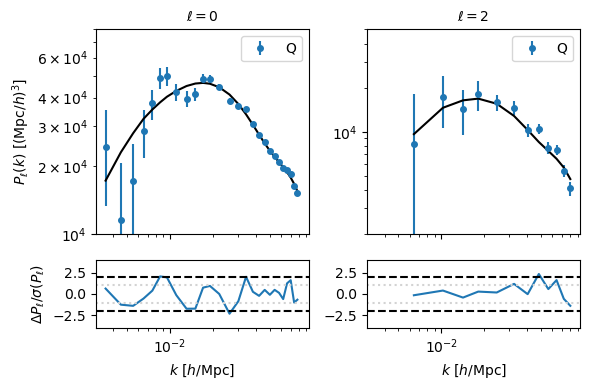

GCcomb 0.004 +-------------------------------------+--------+---------+-------+
| chi2 / (38 - 4) = 40.95 / 34 = 1.20 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -6.2   |  7.6  |
|            QSO_ell0.sn0             |  True  | -0.143  | 0.061 |
|             QSO_ell0.b1             |  True  |  3.222  | 0.057 |
|           QSO_ell0.sigmas           |  True  |  3.90   | 0.50  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.9   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.005 +-------------------------------------+--------+---------+-------+
| chi2 / (37 - 4) = 40.71 / 33 = 1.23 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -4.6   |  8.2  |
|            QSO_ell0.sn0           

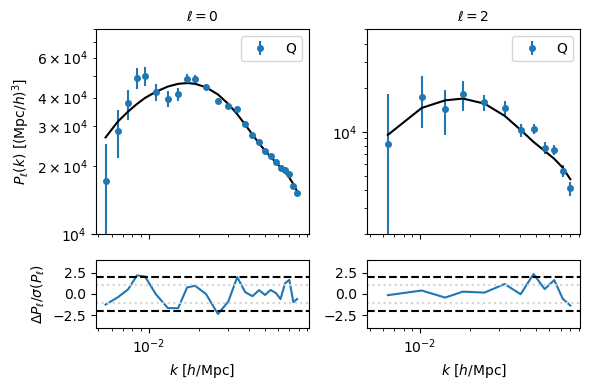

GCcomb 0.006 +-------------------------------------+--------+---------+-------+
| chi2 / (36 - 4) = 39.38 / 32 = 1.23 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -0.6   |  9.1  |
|            QSO_ell0.sn0             |  True  | -0.122  | 0.063 |
|             QSO_ell0.b1             |  True  |  3.194  | 0.061 |
|           QSO_ell0.sigmas           |  True  |  3.84   | 0.52  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.8   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.007 +-------------------------------------+--------+---------+-------+
| chi2 / (34 - 4) = 39.18 / 30 = 1.31 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |    2    |  10.  |
|            QSO_ell0.sn0           

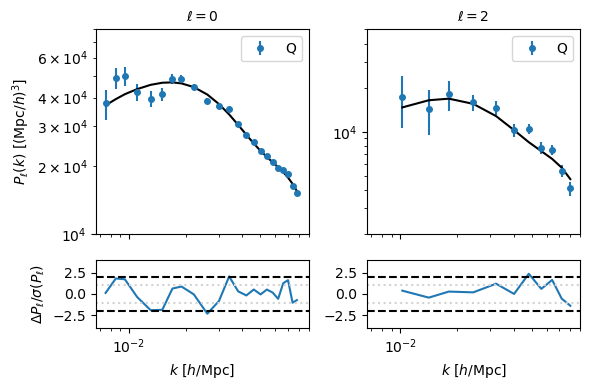

GCcomb 0.008 +-------------------------------------+--------+---------+-------+
| chi2 / (33 - 4) = 39.25 / 29 = 1.35 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |    2    |  11   |
|            QSO_ell0.sn0             |  True  | -0.110  | 0.067 |
|             QSO_ell0.b1             |  True  |  3.181  | 0.068 |
|           QSO_ell0.sigmas           |  True  |  3.83   | 0.52  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.8   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.009 +-------------------------------------+--------+---------+-------+
| chi2 / (32 - 4) = 36.81 / 28 = 1.31 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   -6    |  12   |
|            QSO_ell0.sn0           

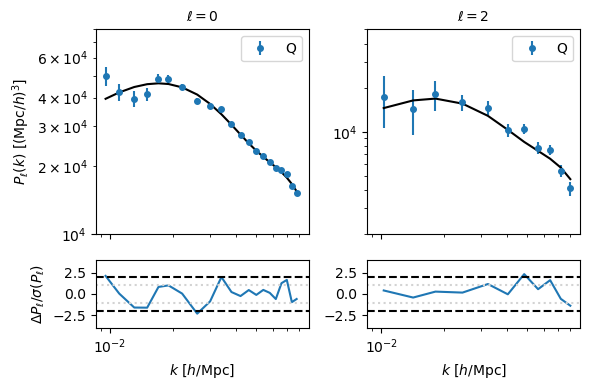

In [70]:
logging.getLogger().setLevel(logging.WARNING)

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

regions = ['SGC', 'NGC', 'GCcomb']

kmins = [1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3]

for region in regions[-1:]:
    for tracer in ['QSO']:
        short_tracer = tracer.replace('_zcmb', '').replace('notqso', '')

        for kmin in kmins:

            pp = pks[region][tracer].select(k=(kmin, 0.2))
            ww = windows[region][tracer].at.observable.match(pp)
            mm = [mock.match(pp) for mock in mocks[region][tracer]]

            obs, lik = get_observable_and_likelihood(pp, ww, mm, short_tracer, zeffs[region], nickname=short_tracer, engine='camb', **kwargs)
            tmp = run_profiler(lik)
            print(region, kmin, tmp.profiles.to_stats(tablefmt="pretty"))

            if kmin in kmins[::2]: plot_observables({short_tracer: obs})


logging.getLogger().setLevel(logging.INFO)

GCcomb 0.001 +-------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 33.81 / 38 = 0.89 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -6.2   |  4.0  |
|            QSO_ell0.sn0             |  True  | -0.131  | 0.055 |
|             QSO_ell0.b1             |  True  |  3.184  | 0.047 |
|           QSO_ell0.sigmas           |  True  |  3.66   | 0.54  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.7   |       |
+-------------------------------------+--------+---------+-------+


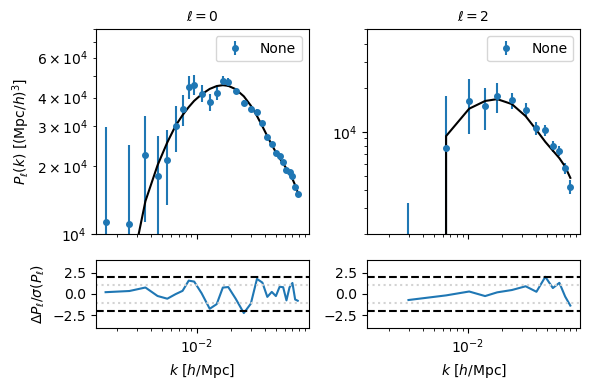

GCcomb 0.002 +-------------------------------------+--------+---------+-------+
| chi2 / (41 - 4) = 33.86 / 37 = 0.92 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -5.3   |  8.7  |
|            QSO_ell0.sn0             |  True  | -0.128  | 0.062 |
|             QSO_ell0.b1             |  True  |  3.179  | 0.060 |
|           QSO_ell0.sigmas           |  True  |  3.65   | 0.54  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.7   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.003 +-------------------------------------+--------+---------+-------+
| chi2 / (39 - 4) = 33.03 / 35 = 0.94 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -4.0   |  8.1  |
|            QSO_ell0.sn0           

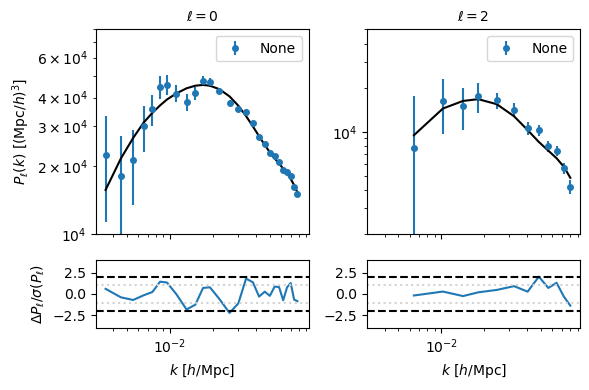

GCcomb 0.004 +-------------------------------------+--------+---------+-------+
| chi2 / (38 - 4) = 32.41 / 34 = 0.95 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -6.2   |  8.1  |
|            QSO_ell0.sn0             |  True  | -0.131  | 0.061 |
|             QSO_ell0.b1             |  True  |  3.184  | 0.058 |
|           QSO_ell0.sigmas           |  True  |  3.67   | 0.54  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.7   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.005 +-------------------------------------+--------+---------+-------+
| chi2 / (37 - 4) = 32.46 / 33 = 0.98 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -5.9   |  8.6  |
|            QSO_ell0.sn0           

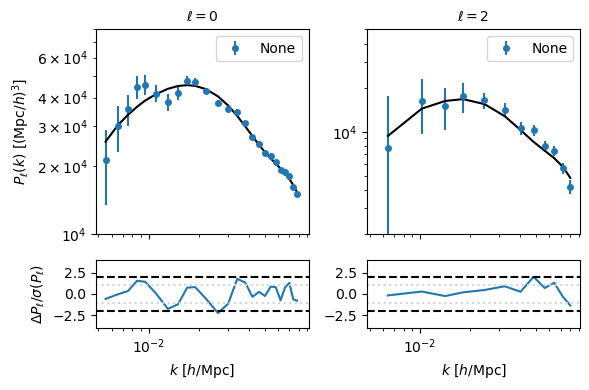

GCcomb 0.006 +-------------------------------------+--------+---------+-------+
| chi2 / (36 - 4) = 32.17 / 32 = 1.01 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |  -3.8   |  9.4  |
|            QSO_ell0.sn0             |  True  | -0.122  | 0.063 |
|             QSO_ell0.b1             |  True  |  3.172  | 0.062 |
|           QSO_ell0.sigmas           |  True  |  3.63   | 0.55  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.6   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.007 +-------------------------------------+--------+---------+-------+
| chi2 / (34 - 4) = 32.25 / 30 = 1.07 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   -4    |  10.  |
|            QSO_ell0.sn0           

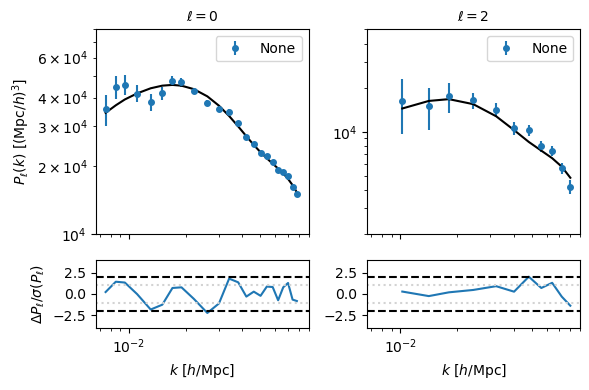

GCcomb 0.008 +-------------------------------------+--------+---------+-------+
| chi2 / (33 - 4) = 32.27 / 29 = 1.11 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   -5    |  11   |
|            QSO_ell0.sn0             |  True  | -0.126  | 0.068 |
|             QSO_ell0.b1             |  True  |  3.178  | 0.069 |
|           QSO_ell0.sigmas           |  True  |  3.65   | 0.55  |
|             QSO_ell2.b1             |  True  |   3.0   |       |
|           QSO_ell2.sigmas           |  True  |   3.7   |       |
+-------------------------------------+--------+---------+-------+
GCcomb 0.009 +-------------------------------------+--------+---------+-------+
| chi2 / (32 - 4) = 30.33 / 28 = 1.08 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   -12   |  12   |
|            QSO_ell0.sn0           

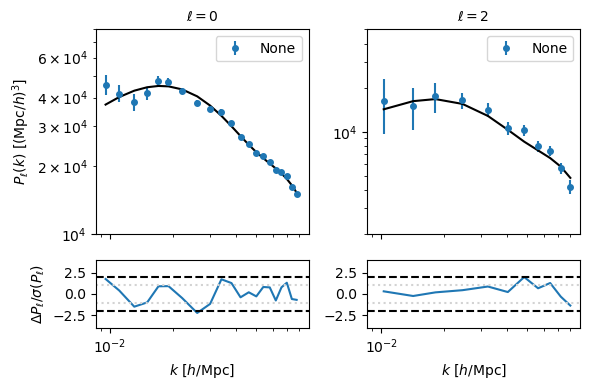

In [99]:
fn = '/Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/mesh2_spectrum_poles_{}_z{}-{}_{}_weight-{}.h5'

import lsstypes
pk_new = lsstypes.read(fn.format('QSO', 0.8, 3.1, 'GCcomb', 'default-fkp-oqe'))

pk_new = pk_new.match(pks['NGC']['QSO'])

logging.getLogger().setLevel(logging.WARNING)

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

regions = ['SGC', 'NGC', 'GCcomb']

kmins = [1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3]

for region in ['GCcomb']:
    for tracer in ['QSO']:
        short_tracer = tracer.replace('_zcmb', '').replace('notqso', '')

        for kmin in kmins:

            pp = pk_new.select(k=(kmin, 0.2))
            ww = windows[region][tracer].at.observable.match(pp)
            mm = [mock.match(pp) for mock in mocks[region][tracer]]

            obs, lik = get_observable_and_likelihood(pp, ww, mm, short_tracer, zeffs[region], nickname=short_tracer, engine='camb', **kwargs)
            tmp = run_profiler(lik)
            print(region, kmin, tmp.profiles.to_stats(tablefmt="pretty"))

            if kmin in kmins[::2]: plot_observables({short_tracer: obs})


logging.getLogger().setLevel(logging.INFO)


In [ ]:
#orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:

    obs = {tracer: get_observable_and_likelihood(pks[tracer], windows[tracer], covs if analytical_covariance else mocks[tracer], 
                                                 tracer, zeffs, nickname=tracer, drop_ell2_cross=True, engine='camb', **kwargs)[-1] for tracer in order}

    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, obs, covs if analytical_covariance else mocks, zeffs, fiducial)

    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tracer: obs[tracer] for tracer in order})